In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import shutil
import numpy as np
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

bestand = Path("/home/niels/BEP-Niels/Data Lobith/data grdc/6435060_Q_Day.Cmd.txt")

df = pd.read_csv(
    bestand,
    sep=";",
    comment="#",
    skipinitialspace=True,
    na_values=-999.000,
    encoding="latin1"
)

df.columns = df.columns.str.strip()

df = df.rename(columns={
    "YYYY-MM-DD": "date",
    "Value": "Q_m3s"
})

df["date"] = pd.to_datetime(df["date"])
df["Q_m3s"] = pd.to_numeric(df["Q_m3s"])

df = df.dropna(subset=["Q_m3s"])

df.head()

,date,hh:mm,Q_m3s
0,1901-01-01,--:--,2035.0
1,1901-01-02,--:--,2270.0
2,1901-01-03,--:--,2445.0
3,1901-01-04,--:--,2325.0
4,1901-01-05,--:--,2175.0


In [2]:
grdc_1920_1935 = df[
    (df["date"] >= "1920-01-01") &
    (df["date"] <= "1935-12-31")
].copy()

grdc_1920_1935.head()

,date,hh:mm,Q_m3s
6939,1920-01-01,--:--,9585.0
6940,1920-01-02,--:--,10000.0
6941,1920-01-03,--:--,9855.0
6942,1920-01-04,--:--,9200.0
6943,1920-01-05,--:--,8400.0


In [3]:
print(grdc_1920_1935["date"].min())
print(grdc_1920_1935["date"].max())
print(len(grdc_1920_1935))

1920-01-01 00:00:00
1935-12-31 00:00:00
5844


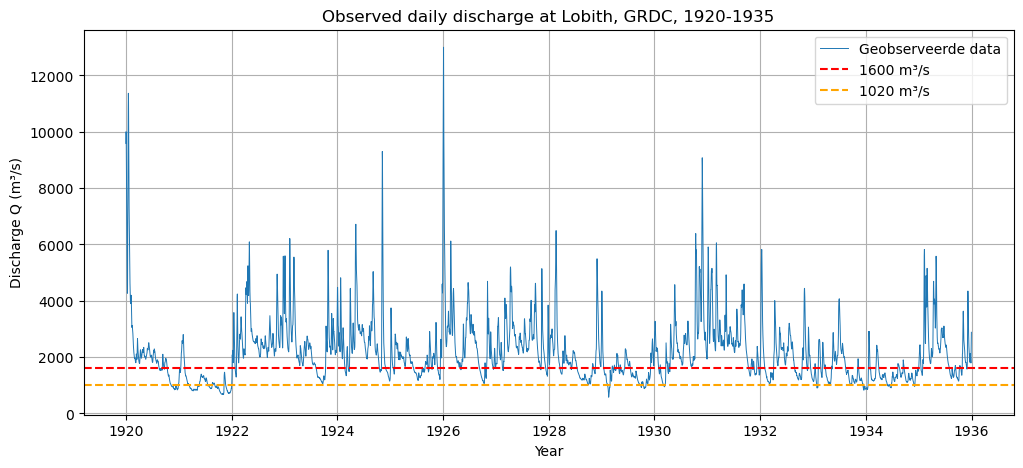

In [4]:
plt.figure(figsize=(12, 5))

plt.plot(
    grdc_1920_1935["date"],
    grdc_1920_1935["Q_m3s"],
    linewidth=0.7,
    label="Geobserveerde data"
)

plt.axhline(1600, linestyle="--", label="1600 m³/s", color='r')
plt.axhline(1020, linestyle="--", label="1020 m³/s", color='orange')

plt.xlabel("Year")
plt.ylabel("Discharge Q (m³/s)")
plt.title("Observed daily discharge at Lobith, GRDC, 1920-1935")
plt.grid()
plt.legend()

plt.show()

In [5]:
grdc_1920_1935["year"] = grdc_1920_1935["date"].dt.year

annual_stats = grdc_1920_1935.groupby("year").agg(
    Q_mean_m3s=("Q_m3s", "mean"),
    Q_min_m3s=("Q_m3s", "min"),
    Q_max_m3s=("Q_m3s", "max"),
    days_below_1600=("Q_m3s", lambda x: (x < 1600).sum()),
    days_below_1020=("Q_m3s", lambda x: (x < 1020).sum())
)

annual_stats

,Q_mean_m3s,Q_min_m3s,Q_max_m3s,days_below_1600,days_below_1020
year,,,,,
1920,2306.051913,835.0,11365.0,103,51
1921,1095.684932,670.0,2800.0,336,209
1922,2788.712329,975.0,6090.0,11,1
1923,2435.424658,1060.0,6210.0,64,0
1924,2695.956284,1145.0,9300.0,64,0
1925,1943.972603,1170.0,7185.0,114,0
1926,2719.767123,1060.0,13000.0,51,0
1927,2664.342466,1320.0,5200.0,22,0
1928,1991.448087,1020.0,6490.0,135,0


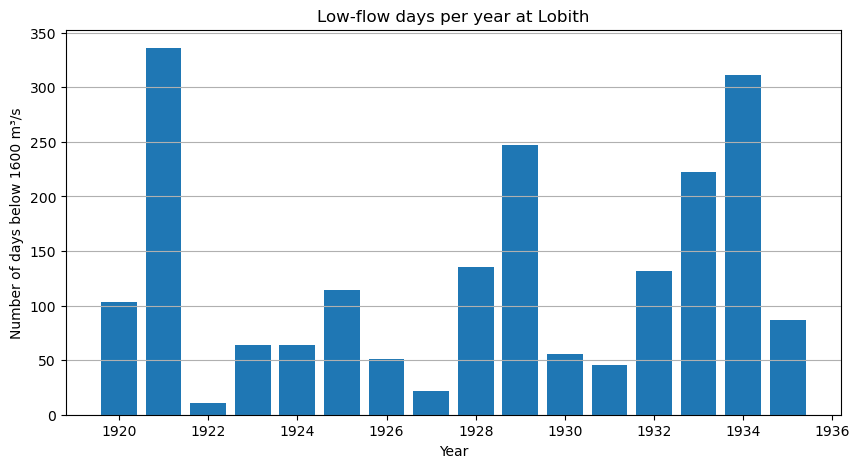

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(
    annual_stats.index,
    annual_stats["days_below_1600"]
)

plt.xlabel("Year")
plt.ylabel("Number of days below 1600 m³/s")
plt.title("Low-flow days per year at Lobith")
plt.grid(axis="y")

plt.show()

In [7]:
project_dir = Path("/home/niels/BEP-Niels")

temp_dir = project_dir / "temp_runs"
results_dir = project_dir / "results"
figures_dir = project_dir / "Results-figures"

temp_dir.mkdir(exist_ok=True)
results_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Temp runs:", temp_dir)
print("Results:", results_dir)
print("Figures:", figures_dir)

Temp runs: /home/niels/BEP-Niels/temp_runs
Results: /home/niels/BEP-Niels/results
Figures: /home/niels/BEP-Niels/Results-figures


In [8]:
mislukte_map = temp_dir / "forcing_wflow_lobith_1990_1991"

if mislukte_map.exists():
    shutil.rmtree(mislukte_map)
    print("Mislukte oude forcingmap verwijderd")
else:
    print("Geen oude mislukte forcingmap gevonden")

Mislukte oude forcingmap verwijderd


In [12]:
start_time = "1991-01-01T00:00:00Z"
end_time = "1992-01-01T00:00:00Z"

run_name = "wflow_lobith_1991_pointcheck"
forcing_directory = temp_dir / f"forcing_{run_name}"

print(forcing_directory)

/home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_pointcheck


In [13]:
shape_file = project_dir / "Rhine" / "Rhine.shp"
dem_file = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map")

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

Shape bestaat: True
DEM bestaat: True


In [14]:
if forcing_directory.exists():
    print("Bestaande forcingmap wordt verwijderd:")
    print(forcing_directory)
    shutil.rmtree(forcing_directory)

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=str(forcing_directory),
)

print("Forcing aangemaakt")
print("Forcing directory:", forcing.directory)

Bestaande forcingmap wordt verwijderd:
/home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_pointcheck
Forcing aangemaakt
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_pointcheck/work/diagnostic/script


In [15]:
def map_grootte_mb(map_pad):
    totaal = 0
    for bestand in Path(map_pad).rglob("*"):
        if bestand.is_file():
            totaal += bestand.stat().st_size
    return totaal / 1_000_000

print("Forcing grootte MB:", map_grootte_mb(forcing_directory))

Forcing grootte MB: 315.477674


In [16]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())

Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True


In [18]:
from pathlib import Path
import shutil
import pandas as pd

project_dir = Path("/home/niels/BEP-Niels")
temp_dir = project_dir / "temp_runs"

def map_grootte_mb(map_pad):
    totaal = 0
    for bestand in Path(map_pad).rglob("*"):
        if bestand.is_file():
            totaal += bestand.stat().st_size
    return totaal / 1_000_000

mappen = []

for item in temp_dir.iterdir():
    if item.is_dir():
        mappen.append({
            "map": item.name,
            "grootte_MB": map_grootte_mb(item)
        })

ruimte_df = pd.DataFrame(mappen).sort_values("grootte_MB", ascending=False)
ruimte_df

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


,map,grootte_MB
0,wflow_forcing_calibrated_2004_2005,6959.018746
2,wflow_base_with_calibrated_infiltration_full,1214.243875
1,wflow_base_with_calibrated_infiltration,1132.479054
4,wflow_20260519_100624,463.995404
5,forcing_wflow_lobith_1991_pointcheck,315.477674
6,wflow_20260519_115429,211.394228
3,.ipynb_checkpoints,0.000000


In [19]:
for item in temp_dir.iterdir():
    if item.is_dir():
        if item.name.startswith("wflow_") or item.name.startswith("forcing_wflow"):
            print("Verwijderen:", item)
            shutil.rmtree(item)

print("Tijdelijke wflow- en forcingmappen verwijderd.")

Verwijderen: /home/niels/BEP-Niels/temp_runs/wflow_forcing_calibrated_2004_2005
Verwijderen: /home/niels/BEP-Niels/temp_runs/wflow_base_with_calibrated_infiltration
Verwijderen: /home/niels/BEP-Niels/temp_runs/wflow_base_with_calibrated_infiltration_full
Verwijderen: /home/niels/BEP-Niels/temp_runs/wflow_20260519_100624
Verwijderen: /home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_pointcheck
Verwijderen: /home/niels/BEP-Niels/temp_runs/wflow_20260519_115429
Tijdelijke wflow- en forcingmappen verwijderd.


In [20]:
mappen = []

for item in temp_dir.iterdir():
    if item.is_dir():
        mappen.append({
            "map": item.name,
            "grootte_MB": map_grootte_mb(item)
        })

ruimte_df = pd.DataFrame(mappen).sort_values("grootte_MB", ascending=False)
ruimte_df

,map,grootte_MB
0,.ipynb_checkpoints,0.0


In [21]:
project_dir = Path("/home/niels/BEP-Niels")
temp_dir = project_dir / "temp_runs"

# totale schijfruimte checken
total, used, free = shutil.disk_usage(project_dir)

print("Totale ruimte GB:", round(total / 1e9, 2))
print("Gebruikt GB:", round(used / 1e9, 2))
print("Vrij GB:", round(free / 1e9, 2))

Totale ruimte GB: 268.3
Gebruikt GB: 258.01
Vrij GB: 10.3


In [25]:
shape_file = project_dir / "Rhine" / "Rhine.shp"
dem_file = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map")

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

Shape bestaat: True
DEM bestaat: True


In [26]:
if forcing_directory.exists():
    print("Bestaande korte forcingmap wordt verwijderd:")
    shutil.rmtree(forcing_directory)

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=str(forcing_directory),
)

print("Forcing aangemaakt")
print("Forcing directory:", forcing.directory)

Forcing aangemaakt
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_pointcheck/work/diagnostic/script


In [27]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

cfg_dir_pointcheck = temp_dir / "wflow_pointcheck_run"

if cfg_dir_pointcheck.exists():
    shutil.rmtree(cfg_dir_pointcheck)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(cfg_dir_pointcheck))
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Output variables:", model.output_var_names)

Start time: 662688000.0
End time: 694224000.0
Output variables: ('RiverRunoff',)


In [28]:
for i in range(20):
    model.update()

print("Modeltijd:", model.time_as_datetime)

Modeltijd: 1991-01-20 00:00:00


In [29]:
lat_lobith_station = 51.84
lon_lobith_station = 6.11

test_lats = np.arange(51.45, 52.15, 0.05)
test_lons = np.arange(5.55, 6.55, 0.05)

punten = []

for lat in test_lats:
    for lon in test_lons:
        try:
            q = model.get_value_at_coords(
                "RiverRunoff",
                lat=[float(lat)],
                lon=[float(lon)]
            )[0]

            afstand = ((lat - lat_lobith_station)**2 + (lon - lon_lobith_station)**2)**0.5

            punten.append({
                "lat": float(lat),
                "lon": float(lon),
                "Q_model_m3s": float(q),
                "afstand": float(afstand)
            })

        except:
            pass

punten_df = pd.DataFrame(punten)

punten_df.sort_values("Q_model_m3s", ascending=False).head(20)

,lat,lon,Q_model_m3s,afstand
99,51.65,6.50,188.137604,0.433820
137,51.75,6.40,180.731949,0.303645
136,51.75,6.35,178.777664,0.256320
155,51.80,6.30,171.988373,0.194165
154,51.80,6.25,166.569260,0.145602
173,51.85,6.20,164.453125,0.090554
172,51.85,6.15,159.742355,0.041231
171,51.85,6.10,155.959702,0.014142
183,51.90,5.70,79.080322,0.414367
182,51.90,5.65,67.935280,0.463897


In [30]:
max_q = punten_df["Q_model_m3s"].max()

print("Maximale gevonden Q:", max_q)

if max_q > 0:
    kandidaten = punten_df[punten_df["Q_model_m3s"] > 0.7 * max_q].copy()
    beste_punt = kandidaten.sort_values("afstand").iloc[0]

    lat_lobith_model = beste_punt["lat"]
    lon_lobith_model = beste_punt["lon"]

    print("Gekozen Lobith-modelpunt:")
    print("Latitude:", lat_lobith_model)
    print("Longitude:", lon_lobith_model)
    print("Q op testmoment:", beste_punt["Q_model_m3s"])

    lobith_point = pd.DataFrame([{
        "station": "Lobith",
        "lat_model": lat_lobith_model,
        "lon_model": lon_lobith_model,
        "lat_station": lat_lobith_station,
        "lon_station": lon_lobith_station,
        "Q_test_m3s": beste_punt["Q_model_m3s"]
    }])

    lobith_point_file = results_dir / "lobith_model_point_wflow.csv"
    lobith_point.to_csv(lobith_point_file, index=False)

    print("Opgeslagen als:", lobith_point_file)

else:
    print("Alle punten zijn 0. Dan zit het probleem niet in het Lobith-punt, maar in model/forcing.")

Maximale gevonden Q: 188.13760375976562
Gekozen Lobith-modelpunt:
Latitude: 51.84999999999998
Longitude: 6.099999999999998
Q op testmoment: 155.95970153808594
Opgeslagen als: /home/niels/BEP-Niels/results/lobith_model_point_wflow.csv


In [31]:
model.finalize()

shutil.rmtree(cfg_dir_pointcheck, ignore_errors=True)
shutil.rmtree(forcing_directory, ignore_errors=True)

print("Model afgesloten")
print("Korte forcing en tijdelijke modelmap verwijderd")

Model afgesloten
Korte forcing en tijdelijke modelmap verwijderd


In [32]:
start_time = "1991-01-01T00:00:00Z"
end_time = "1993-01-01T00:00:00Z"

calibration_start = "1992-01-01"
calibration_end = "1992-12-31"

run_name = "wflow_lobith_1991_1992"

forcing_directory = temp_dir / f"forcing_{run_name}"
cfg_dir_run = temp_dir / f"run_{run_name}"

print("Forcing directory:", forcing_directory)
print("Model run directory:", cfg_dir_run)

Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_1992
Model run directory: /home/niels/BEP-Niels/temp_runs/run_wflow_lobith_1991_1992


In [33]:
WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=str(forcing_directory),
)

print("Forcing aangemaakt")
print("Forcing directory:", forcing.directory)

Forcing aangemaakt
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_wflow_lobith_1991_1992/work/diagnostic/script


In [35]:
lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Lobith modelpunt:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Lobith modelpunt:
Latitude: 51.849999998
Longitude: 6.0999999998


In [36]:
total, used, free = shutil.disk_usage(project_dir)

print("Vrije ruimte GB:", round(free / 1e9, 2))
print("Forcing grootte MB:", round(map_grootte_mb(forcing_directory), 1))

Vrije ruimte GB: 9.82
Forcing grootte MB: 472.8


In [37]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Config bestaat:", parameter_set.config.exists())

Config bestaat: True


In [38]:
if cfg_dir_run.exists():
    print("Oude modelrunmap wordt verwijderd:")
    print(cfg_dir_run)
    shutil.rmtree(cfg_dir_run)

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(cfg_dir_run))
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Output variables:", model.output_var_names)

Start time: 662688000.0
End time: 725846400.0
Output variables: ('RiverRunoff',)


In [39]:
Q_model = []
time_model = []

i = 0

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[float(lat_lobith_model)],
        lon=[float(lon_lobith_model)]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)
    
    i += 1
    
    if i % 100 == 0:
        print("Stap:", i, "Tijd:", model.time_as_datetime, "Q:", float(q_lobith))

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model, utc=True),
    "Q_model_m3s": Q_model
})

model_output["date"] = model_output["date"].dt.tz_convert(None).dt.floor("D")

model_output.head()

Stap: 100 Tijd: 1991-04-10 00:00:00 Q: 950.380126953125
Stap: 200 Tijd: 1991-07-19 00:00:00 Q: 763.1840209960938
Stap: 300 Tijd: 1991-10-27 00:00:00 Q: 1803.3531494140625
Stap: 400 Tijd: 1992-02-04 00:00:00 Q: 607.1539306640625
Stap: 500 Tijd: 1992-05-14 00:00:00 Q: 1852.216796875
Stap: 600 Tijd: 1992-08-22 00:00:00 Q: 616.5467529296875
Stap: 700 Tijd: 1992-11-30 00:00:00 Q: 8264.458984375


,date,Q_model_m3s
0,1991-01-01,0.000794
1,1991-01-02,0.203240
2,1991-01-03,0.261454
3,1991-01-04,0.295617
4,1991-01-05,0.367961


In [40]:
model.finalize()

print("Model afgesloten")

Model afgesloten


In [41]:
print("Min Q:", model_output["Q_model_m3s"].min())
print("Max Q:", model_output["Q_model_m3s"].max())
print("Mean Q:", model_output["Q_model_m3s"].mean())

model_output.head()

Min Q: 0.0007941406220197678
Max Q: 12492.3798828125
Mean Q: 2115.7720392997367


,date,Q_model_m3s
0,1991-01-01,0.000794
1,1991-01-02,0.203240
2,1991-01-03,0.261454
3,1991-01-04,0.295617
4,1991-01-05,0.367961


In [42]:
model_output_1992 = model_output[
    (model_output["date"] >= calibration_start) &
    (model_output["date"] <= calibration_end)
].copy()

print("Start vergelijking:", model_output_1992["date"].min())
print("Einde vergelijking:", model_output_1992["date"].max())
print("Aantal dagen:", len(model_output_1992))

output_file = results_dir / "wflow_lobith_1992_daily.csv"
model_output_1992.to_csv(output_file, index=False)

print("Modeloutput opgeslagen als:")
print(output_file)

Start vergelijking: 1992-01-01 00:00:00
Einde vergelijking: 1992-12-31 00:00:00
Aantal dagen: 366
Modeloutput opgeslagen als:
/home/niels/BEP-Niels/results/wflow_lobith_1992_daily.csv


In [43]:
figures_dir = project_dir / "figures"

In [45]:
project_dir = Path("/home/niels/BEP-Niels")
results_dir = project_dir / "results"

calibration_start = "1992-01-01"
calibration_end = "1992-12-31"

# Wflow-output opnieuw inlezen vanuit results
model_file = results_dir / "wflow_lobith_1992_daily.csv"

model_output_1992 = pd.read_csv(model_file)
model_output_1992["date"] = pd.to_datetime(model_output_1992["date"])

model_output_1992.head()

,date,Q_model_m3s
0,1992-01-01,4977.022461
1,1992-01-02,4200.267578
2,1992-01-03,3560.075439
3,1992-01-04,3080.268311
4,1992-01-05,2791.143799


In [46]:
grdc_1992 = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_1992 = grdc_1992[["date", "Q_m3s"]]
grdc_1992 = grdc_1992.rename(columns={"Q_m3s": "Q_grdc_m3s"})

comparison = pd.merge(
    grdc_1992,
    model_output_1992,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison))
comparison.head()

Aantal overlappende dagen: 366


,date,Q_grdc_m3s,Q_model_m3s
0,1992-01-01,2830.0,4977.022461
1,1992-01-02,2592.0,4200.267578
2,1992-01-03,2385.0,3560.075439
3,1992-01-04,2182.0,3080.268311
4,1992-01-05,2051.0,2791.143799


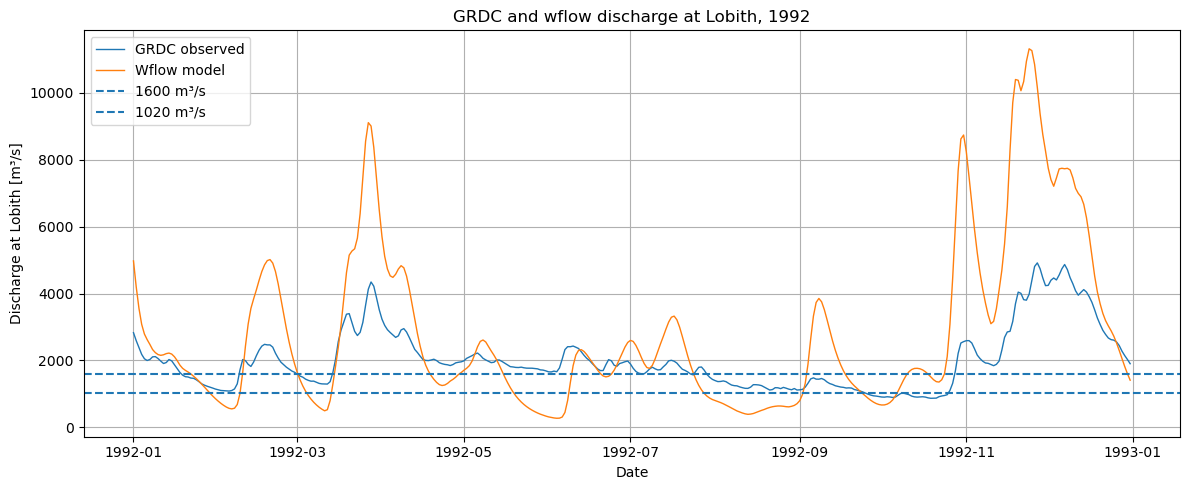

Figuur opgeslagen als:
/home/niels/BEP-Niels/figures/grdc_wflow_lobith_1992.png


In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["date"],
    comparison["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison["date"],
    comparison["Q_model_m3s"],
    label="Wflow model",
    linewidth=1.0
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("GRDC and wflow discharge at Lobith, 1992")
plt.grid()
plt.legend()

plt.tight_layout()

figure_file = figures_dir / "grdc_wflow_lobith_1992.png"
plt.savefig(figure_file, dpi=200)

plt.show()

print("Figuur opgeslagen als:")
print(figure_file)

In [48]:
# Basisrun voor kalibratie: 1980-1990

start_time = "1979-01-01T00:00:00Z"
end_time = "1991-01-01T00:00:00Z"

calibration_start = "1980-01-01"
calibration_end = "1990-12-31"

run_name = "basisrun_1980_1990"

forcing_directory = temp_dir / f"forcing_{run_name}"
cfg_dir_run = temp_dir / f"run_{run_name}"

print("Model start:", start_time)
print("Model end:", end_time)
print("Vergelijking start:", calibration_start)
print("Vergelijking eind:", calibration_end)

print("Forcing directory:", forcing_directory)
print("Model run directory:", cfg_dir_run)

Model start: 1979-01-01T00:00:00Z
Model end: 1991-01-01T00:00:00Z
Vergelijking start: 1980-01-01
Vergelijking eind: 1990-12-31
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1980_1990
Model run directory: /home/niels/BEP-Niels/temp_runs/run_basisrun_1980_1990


In [49]:
# GRDC-data selecteren voor 1980-1990

grdc_calibration = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_m3s"]]
grdc_calibration = grdc_calibration.rename(columns={"Q_m3s": "Q_grdc_m3s"})

print("Start GRDC:", grdc_calibration["date"].min())
print("Einde GRDC:", grdc_calibration["date"].max())
print("Aantal dagen:", len(grdc_calibration))

grdc_calibration.head()

Start GRDC: 1980-01-01 00:00:00
Einde GRDC: 1990-12-31 00:00:00
Aantal dagen: 4018


,date,Q_grdc_m3s
28854,1980-01-01,2888.0
28855,1980-01-02,2935.0
28856,1980-01-03,2878.0
28857,1980-01-04,2724.0
28858,1980-01-05,2573.0


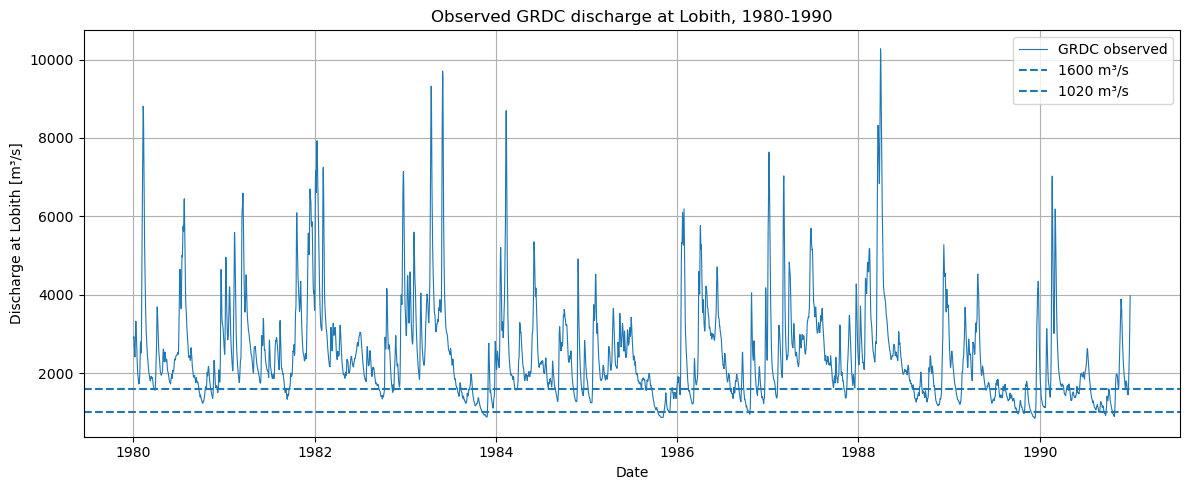

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(
    grdc_calibration["date"],
    grdc_calibration["Q_grdc_m3s"],
    linewidth=0.8,
    label="GRDC observed"
)

plt.axhline(1600, linestyle="--", label="1600 m³/s")
plt.axhline(1020, linestyle="--", label="1020 m³/s")

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("Observed GRDC discharge at Lobith, 1980-1990")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# Basisrun met beschikbare ERA5-data

start_time = "1986-01-01T00:00:00Z"
end_time = "1991-01-01T00:00:00Z"

calibration_start = "1987-01-01"
calibration_end = "1990-12-31"

run_name = "basisrun_1987_1990"

forcing_directory = temp_dir / f"forcing_{run_name}"
cfg_dir_run = temp_dir / f"run_{run_name}"

print("Model start:", start_time)
print("Model end:", end_time)
print("Vergelijking start:", calibration_start)
print("Vergelijking eind:", calibration_end)

print("Forcing directory:", forcing_directory)
print("Model run directory:", cfg_dir_run)

Model start: 1986-01-01T00:00:00Z
Model end: 1991-01-01T00:00:00Z
Vergelijking start: 1987-01-01
Vergelijking eind: 1990-12-31
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1990
Model run directory: /home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990


In [55]:
shape_file = project_dir / "Rhine" / "Rhine.shp"
dem_file = Path("/data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map")

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

print("Shape file:", shape_file)
print("DEM file:", dem_file)

Shape bestaat: True
DEM bestaat: True
Shape file: /home/niels/BEP-Niels/Rhine/Rhine.shp
DEM file: /data/shared/parameter-sets/wflow_rhine_sbm_nc/staticmaps/wflow_dem.map


In [56]:
# Forcing maken voor de basisrun 1980-1990
# Let op: 1979 is het inspeeljaar

if forcing_directory.exists():
    print("Bestaande forcingmap wordt verwijderd:")
    print(forcing_directory)
    shutil.rmtree(forcing_directory)

WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=str(forcing_directory),
)

print("Forcing aangemaakt")
print("Forcing directory:", forcing.directory)

Forcing aangemaakt
Forcing directory: /home/niels/BEP-Niels/temp_runs/forcing_basisrun_1987_1990/work/diagnostic/script


In [57]:
print("Forcing grootte MB:", round(map_grootte_mb(forcing_directory), 1))

total, used, free = shutil.disk_usage(project_dir)

print("Vrije ruimte GB:", round(free / 1e9, 2))

Forcing grootte MB: 944.9
Vrije ruimte GB: 20.83


In [58]:
lat_lobith_model = 51.849999998
lon_lobith_model = 6.0999999998

print("Lobith modelpunt:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Lobith modelpunt:
Latitude: 51.849999998
Longitude: 6.0999999998


In [59]:
if cfg_dir_run.exists():
    print("Oude modelrunmap wordt verwijderd:")
    print(cfg_dir_run)
    shutil.rmtree(cfg_dir_run)

print("Nieuwe modelrunmap:")
print(cfg_dir_run)

Nieuwe modelrunmap:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990


In [61]:
parameter_sets = available_parameter_sets(target_model="wflow")
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Parameter set:", parameter_set.directory)
print("Config bestaat:", parameter_set.config.exists())

Parameter set: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config bestaat: True


In [63]:
# Oude modelrun netjes opruimen

try:
    model.finalize()
except:
    pass

cfg_dir_run = temp_dir / "run_basisrun_1987_1990"

if cfg_dir_run.exists():
    print("Oude runmap verwijderen:")
    print(cfg_dir_run)
    shutil.rmtree(cfg_dir_run)

print("Bestaat runmap nog?", cfg_dir_run.exists())

Oude runmap verwijderen:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990
Bestaat runmap nog? False


In [64]:
model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup(cfg_dir=str(cfg_dir_run))
model.initialize(cfg_file)

print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Output variables:", model.output_var_names)

Start time: 504921600.0
End time: 662688000.0
Output variables: ('RiverRunoff',)


In [65]:
Q_model = []
time_model = []

i = 0

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[float(lat_lobith_model)],
        lon=[float(lon_lobith_model)]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)
    
    i += 1
    
    if i % 365 == 0:
        print("Stap:", i, "Tijd:", model.time_as_datetime, "Q:", round(float(q_lobith), 1))

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model, utc=True),
    "Q_model_m3s": Q_model
})

model_output["date"] = model_output["date"].dt.tz_convert(None).dt.floor("D")

model_output.head()

Stap: 365 Tijd: 1986-12-31 00:00:00 Q: 11876.8
Stap: 730 Tijd: 1987-12-31 00:00:00 Q: 2224.0
Stap: 1095 Tijd: 1988-12-30 00:00:00 Q: 3958.7
Stap: 1460 Tijd: 1989-12-30 00:00:00 Q: 4676.8
Stap: 1825 Tijd: 1990-12-30 00:00:00 Q: 6410.8


,date,Q_model_m3s
0,1986-01-01,0.000008
1,1986-01-02,0.080924
2,1986-01-03,0.216883
3,1986-01-04,0.213483
4,1986-01-05,0.387448


In [66]:
model.finalize()

print("Model afgesloten")

Model afgesloten


In [67]:
print("Aantal dagen modeloutput:", len(model_output))
print("Start modeloutput:", model_output["date"].min())
print("Einde modeloutput:", model_output["date"].max())

print("Min Q:", model_output["Q_model_m3s"].min())
print("Max Q:", model_output["Q_model_m3s"].max())
print("Mean Q:", model_output["Q_model_m3s"].mean())

Aantal dagen modeloutput: 1827
Start modeloutput: 1986-01-01 00:00:00
Einde modeloutput: 1991-01-01 00:00:00
Min Q: 8.140679710777476e-06
Max Q: 18166.568359375
Mean Q: 2999.607516387636


In [68]:
# GRDC en wflow modeloutput combineren voor vergelijking

# Zorg dat dates netjes datetime zijn
df["date"] = pd.to_datetime(df["date"])
model_output["date"] = pd.to_datetime(model_output["date"]).dt.floor("D")

# Alleen vergelijkingsperiode selecteren
grdc_calibration = df[
    (df["date"] >= calibration_start) &
    (df["date"] <= calibration_end)
].copy()

grdc_calibration = grdc_calibration[["date", "Q_m3s"]]
grdc_calibration = grdc_calibration.rename(columns={"Q_m3s": "Q_grdc_m3s"})

model_calibration = model_output[
    (model_output["date"] >= calibration_start) &
    (model_output["date"] <= calibration_end)
].copy()

model_calibration = model_calibration[["date", "Q_model_m3s"]]

# Samenvoegen op datum
comparison = pd.merge(
    grdc_calibration,
    model_calibration,
    on="date",
    how="inner"
)

print("Aantal vergelijkingsdagen:", len(comparison))
print("Start:", comparison["date"].min())
print("Einde:", comparison["date"].max())

comparison.head()

Aantal vergelijkingsdagen: 1461
Start: 1987-01-01 00:00:00
Einde: 1990-12-31 00:00:00


,date,Q_grdc_m3s,Q_model_m3s
0,1987-01-01,4865.0,13869.678711
1,1987-01-02,5756.0,15741.568359
2,1987-01-03,6160.0,16061.675781
3,1987-01-04,6973.0,15124.300781
4,1987-01-05,7579.0,13978.630859


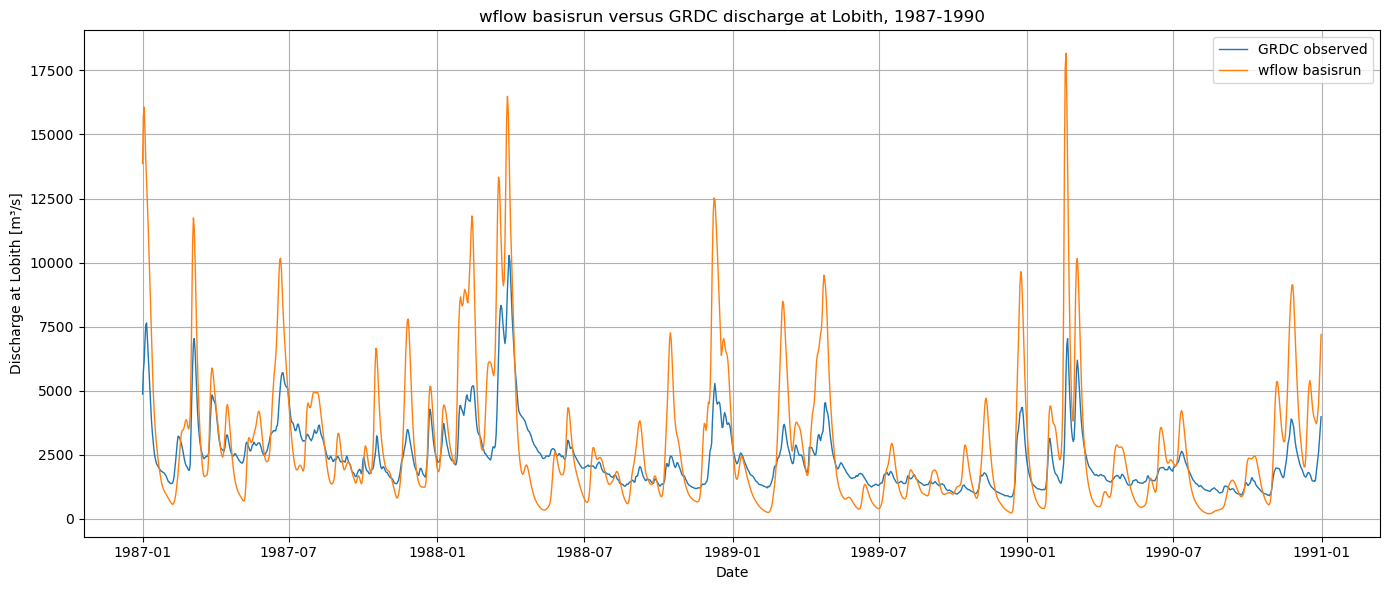

In [69]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["date"],
    comparison["Q_grdc_m3s"],
    label="GRDC observed",
    linewidth=1.0
)

plt.plot(
    comparison["date"],
    comparison["Q_model_m3s"],
    label="wflow basisrun",
    linewidth=1.0
)

plt.xlabel("Date")
plt.ylabel("Discharge at Lobith [m³/s]")
plt.title("wflow basisrun versus GRDC discharge at Lobith, 1987-1990")
plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

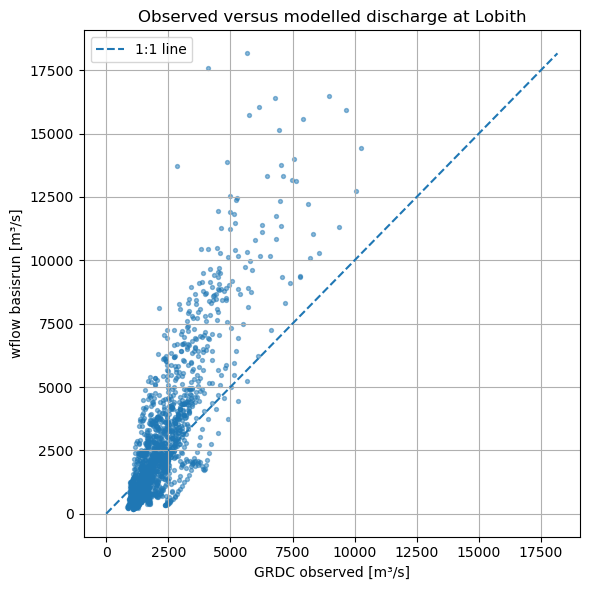

In [70]:
plt.figure(figsize=(6, 6))

plt.scatter(
    comparison["Q_grdc_m3s"],
    comparison["Q_model_m3s"],
    s=8,
    alpha=0.5
)

max_q = max(
    comparison["Q_grdc_m3s"].max(),
    comparison["Q_model_m3s"].max()
)

plt.plot([0, max_q], [0, max_q], linestyle="--", label="1:1 line")

plt.xlabel("GRDC observed [m³/s]")
plt.ylabel("wflow basisrun [m³/s]")
plt.title("Observed versus modelled discharge at Lobith")
plt.grid()
plt.legend()
plt.tight_layout()

plt.show()

In [71]:
# Check welke parameterkaarten beschikbaar zijn in de runmap

staticmaps_dir = cfg_dir_run / "staticmaps"

print("Staticmaps map:")
print(staticmaps_dir)
print("Bestaat:", staticmaps_dir.exists())

map_files = sorted(staticmaps_dir.glob("*.map"))

print("Aantal map-bestanden:", len(map_files))

for file in map_files:
    print(file.name)

Staticmaps map:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990/staticmaps
Bestaat: True
Aantal map-bestanden: 31
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map


In [72]:
zoekwoorden = [
    "N",
    "River",
    "M",
    "Soil",
    "Thickness",
    "Ksat",
    "Root",
    "theta"
]

for woord in zoekwoorden:
    print("\n---", woord, "---")
    
    gevonden = False
    
    for file in map_files:
        if woord.lower() in file.name.lower():
            print(file.name)
            gevonden = True
    
    if not gevonden:
        print("Niets gevonden")


--- N ---
ChannelDepth.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_demmin.map
wflow_landuse.map
wflow_riverburnin.map
wflow_riverlength_fact.map

--- River ---
RiverWidth.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map

--- M ---
ChannelDepth.map
DCL.map
RiverWidth.map
cc.map
cutout.map
dem.map
gauges.map
tt.map
ttt.map
wflow_bankfulldepth.map
wflow_catchment.map
wflow_dem.map
wflow_dem10.map
wflow_dem25.map
wflow_dem33.map
wflow_dem66.map
wflow_dem75.map
wflow_dem90.map
wflow_demmax.map
wflow_demmin.map
wflow_gauges.map
wflow_landuse.map
wflow_ldd.map
wflow_outlet.map
wflow_river.map
wflow_riverburnin.map
wflow_riverdem.map
wflow_riverlength_fact.map
wflow_soil.map
wflow_streamorder.map
wflow_subcatch.map

--- Soil ---
wflow_soil.map

--- Thickness ---
Niets gevonden

--- Ksat ---
Niets gevonden

--- Root ---
Niets gevonden

--- theta ---
Niets gevonden


In [73]:
cfg_dir_path = Path(cfg_dir)

print("Config file:")
print(cfg_file)

print("\nRun directory:")
print(cfg_dir_path)

print("\nBestanden in de run directory:")

for file in sorted(cfg_dir_path.rglob("*")):
    if file.is_file():
        print(file.relative_to(cfg_dir_path))

Config file:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990/wflow_ewatercycle.ini

Run directory:
/home/niels/BEP-Niels/temp_runs/run_basisrun_1987_1990

Bestanden in de run directory:
inmaps.nc
instates.nc
intbl/CanopyGapFraction.tbl
intbl/Cfmax.tbl
intbl/EoverR.tbl
intbl/FirstZoneCapacity.tbl
intbl/FirstZoneKsatVer.tbl
intbl/FirstZoneMinCapacity.tbl
intbl/InfiltCapPath.tbl
intbl/InfiltCapSoil.tbl
intbl/M.tbl
intbl/MaxCanopyStorage.tbl
intbl/MaxLeakage.tbl
intbl/N.tbl
intbl/N_Floodplain.tbl
intbl/N_Floodplain.txt
intbl/N_River.tbl
intbl/PathFrac.tbl
intbl/RootingDepth.tbl
intbl/TT.tbl
intbl/TTI.tbl
intbl/WHC.tbl
intbl/cf_soil.tbl
intbl/thetaR.tbl
intbl/thetaS.tbl
intss/Lobith.tss
intss/Lobith1200.tss
intss/Lobith3600.tss
intss/Lobith600.tss
intss/update.tss
run_default/configofrun.ini
run_default/intbl/CanopyGapFraction.tbl
run_default/intbl/Cfmax.tbl
run_default/intbl/EoverR.tbl
run_default/intbl/FirstZoneCapacity.tbl
run_default/intbl/FirstZoneKsatVer.tbl
run_default/intbl/F

In [75]:
cfg_path = Path(cfg_file)

text = cfg_path.read_text()

zoekwoorden = [
    "N_River",
    "n_river",
    "manning",
    "M",
    "SoilThickness",
    "soilthickness",
    "Ksat",
    "KsatVer",
    "KsatHor",
    "theta",
    "RootingDepth",
    "root",
    "landuse",
    "soil",
    "river"
]

for line in text.splitlines():
    line_lower = line.lower()
    
    for woord in zoekwoorden:
        if woord.lower() in line_lower:
            print(line)
            break

[inputmapstacks]
Temperature = /tas
Inflow = /inmaps/IF
[modelparameters]
starttime = 1986-01-01 00:00:00
endtime = 1991-01-01 00:00:00
timestepsecs = 86400
[model]
modeltype = sbm
ModelSnow = 0
InterpolationMethod = inv
WIMaxScale = 0.8
UpdMaxDist = 300000.0
[misc]
[framework]
netcdfoutput = outmaps.nc
sizeinmetres = 0
[outputmaps]
self.RiverRunoff = run
self.InwaterMM = iwm
[summary]
self.MaxLeakage = MaxLeakage.map
[summary_sum]
self.Precipitation = Sumprecip.map
[summary_max]
self.Precipitation = maxprecip.map
[summary_min]
[summary_avg]
self.Precipitation = avgprecip.map
samplemap = staticmaps/wflow_landuse.map
samplemap = staticmaps/wflow_gauges.map
self.RiverRunoff = run.tss
samplemap = staticmaps/wflow_gauges.map
RiverRunoff = 2, m/s


In [76]:
import xarray as xr

nc_files = sorted(cfg_dir_path.rglob("*.nc"))

print("Aantal NetCDF-bestanden:", len(nc_files))

for nc_file in nc_files:
    print("\n---")
    print(nc_file.relative_to(cfg_dir_path))
    
    try:
        ds = xr.open_dataset(nc_file)
        print("Variabelen:")
        for var in ds.data_vars:
            print("  ", var)
        ds.close()
    except Exception as e:
        print("Kon bestand niet openen:", e)

Aantal NetCDF-bestanden: 5

---
inmaps.nc
Variabelen:
   projection
   P
   PET
   TEMP

---
instates.nc
Variabelen:
   crs
   SurfaceRunoff.map
   WaterLevel.map
   FirstZoneDepth.map
   Snow.map
   TSoil.map
   UStoreDepth.map
   SnowWater.map
   CanopyStorage.map
   LowerZoneStorage.map

---
run_default/outmaps.nc
Variabelen:
   crs
   iflow
   run
   iwm
   PET
   P

---
staticmaps.nc
Variabelen:
   crs
   wflow_bankfulldepth.map
   wflow_catchment.map
   wflow_dem.map
   wflow_dem10.map
   wflow_dem25.map
   wflow_dem33.map
   wflow_dem66.map
   wflow_dem75.map
   wflow_dem90.map
   wflow_demmax.map
   wflow_demmin.map
   wflow_gauges.map
   wflow_landuse.map
   wflow_ldd.map
   wflow_outlet.map
   wflow_river.map
   wflow_riverburnin.map
   wflow_riverdem.map
   wflow_riverlength_fact.map
   wflow_soil.map
   wflow_streamorder.map
   wflow_subcatch.map

---
wflow_ERA5_Rhine_1986_1991.nc
Variabelen:
   pr
   time_bnds
   lat_bnds
   lon_bnds
   tas
   pet


In [77]:
# Zoek alle tabelbestanden in de runmap

cfg_dir_path = Path(cfg_dir)

tbl_files = sorted(cfg_dir_path.rglob("*.tbl"))

print("Aantal .tbl bestanden:", len(tbl_files))

for file in tbl_files:
    print(file.relative_to(cfg_dir_path))

Aantal .tbl bestanden: 44
intbl/CanopyGapFraction.tbl
intbl/Cfmax.tbl
intbl/EoverR.tbl
intbl/FirstZoneCapacity.tbl
intbl/FirstZoneKsatVer.tbl
intbl/FirstZoneMinCapacity.tbl
intbl/InfiltCapPath.tbl
intbl/InfiltCapSoil.tbl
intbl/M.tbl
intbl/MaxCanopyStorage.tbl
intbl/MaxLeakage.tbl
intbl/N.tbl
intbl/N_Floodplain.tbl
intbl/N_River.tbl
intbl/PathFrac.tbl
intbl/RootingDepth.tbl
intbl/TT.tbl
intbl/TTI.tbl
intbl/WHC.tbl
intbl/cf_soil.tbl
intbl/thetaR.tbl
intbl/thetaS.tbl
run_default/intbl/CanopyGapFraction.tbl
run_default/intbl/Cfmax.tbl
run_default/intbl/EoverR.tbl
run_default/intbl/FirstZoneCapacity.tbl
run_default/intbl/FirstZoneKsatVer.tbl
run_default/intbl/FirstZoneMinCapacity.tbl
run_default/intbl/InfiltCapPath.tbl
run_default/intbl/InfiltCapSoil.tbl
run_default/intbl/M.tbl
run_default/intbl/MaxCanopyStorage.tbl
run_default/intbl/MaxLeakage.tbl
run_default/intbl/N.tbl
run_default/intbl/N_Floodplain.tbl
run_default/intbl/N_River.tbl
run_default/intbl/PathFrac.tbl
run_default/intbl/Rootin

In [78]:
# Zoek naar relevante parameterbestanden

zoekwoorden = [
    "N",
    "River",
    "M",
    "Ksat",
    "Soil",
    "Thickness",
    "Root",
    "theta",
    "Infilt",
    "Leakage"
]

for woord in zoekwoorden:
    print("\n---", woord, "---")
    
    gevonden = False
    
    for file in tbl_files:
        if woord.lower() in file.name.lower():
            print(file.relative_to(cfg_dir_path))
            gevonden = True
    
    if not gevonden:
        print("Niets gevonden")


--- N ---
intbl/CanopyGapFraction.tbl
intbl/FirstZoneCapacity.tbl
intbl/FirstZoneKsatVer.tbl
intbl/FirstZoneMinCapacity.tbl
intbl/InfiltCapPath.tbl
intbl/InfiltCapSoil.tbl
intbl/MaxCanopyStorage.tbl
intbl/N.tbl
intbl/N_Floodplain.tbl
intbl/N_River.tbl
intbl/RootingDepth.tbl
run_default/intbl/CanopyGapFraction.tbl
run_default/intbl/FirstZoneCapacity.tbl
run_default/intbl/FirstZoneKsatVer.tbl
run_default/intbl/FirstZoneMinCapacity.tbl
run_default/intbl/InfiltCapPath.tbl
run_default/intbl/InfiltCapSoil.tbl
run_default/intbl/MaxCanopyStorage.tbl
run_default/intbl/N.tbl
run_default/intbl/N_Floodplain.tbl
run_default/intbl/N_River.tbl
run_default/intbl/RootingDepth.tbl

--- River ---
intbl/N_River.tbl
run_default/intbl/N_River.tbl

--- M ---
intbl/Cfmax.tbl
intbl/FirstZoneMinCapacity.tbl
intbl/M.tbl
intbl/MaxCanopyStorage.tbl
intbl/MaxLeakage.tbl
run_default/intbl/Cfmax.tbl
run_default/intbl/FirstZoneMinCapacity.tbl
run_default/intbl/M.tbl
run_default/intbl/MaxCanopyStorage.tbl
run_default/

In [79]:
# Inhoud van mogelijke kalibratietabellen bekijken

kandidaat_woorden = [
    "N",
    "River",
    "M",
    "Ksat",
    "Soil",
    "Thickness"
]

for file in tbl_files:
    if any(woord.lower() in file.name.lower() for woord in kandidaat_woorden):
        print("\n==============================")
        print(file.relative_to(cfg_dir_path))
        print("==============================")
        
        try:
            print(file.read_text()[:1500])
        except:
            print("Kon bestand niet als tekst lezen")


intbl/CanopyGapFraction.tbl
1	<,14]	1 0.8
2	<,14]	1 0.5
3	<,14]	1 0.1
4	<,14]	1 0.5
5	<,14]	1 0.8
6	<,14]	1 0.8

intbl/Cfmax.tbl
<,7]  <,14] 1 3.75653

intbl/FirstZoneCapacity.tbl
1	1	1	400
2	1	1	7100
3	1	1	7100
4	1	1	7100
5	1	1	7100
6	1	1	7100
1	2	1	3200
2	2	1	10000
3	2	1	10000
4	2	1	10000
5	2	1	10000
6	2	1	10000
1	3	1	400
2	3	1	1000
3	3	1	1000
4	3	1	1000
5	3	1	1000
6	3	1	1000
1	4	1	800
2	4	1	14200
3	4	1	14200
4	4	1	14200
5	4	1	14200
6	4	1	14200
1	5	1	800
2	5	1	14200
3	5	1	14200
4	5	1	14200
5	5	1	14200
6	5	1	14200
1	6	1	800
2	6	1	14200
3	6	1	14200
4	6	1	14200
5	6	1	14200
6	6	1	14200
1	7	1	1200
2	7	1	6750
3	7	1	6750
4	7	1	6750
5	7	1	6750
6	7	1	6750
1	8	1	400
2	8	1	1750
3	8	1	1750
4	8	1	1750
5	8	1	1750
6	8	1	1750
1	9	1	800
2	9	1	14200
3	9	1	14200
4	9	1	14200
5	9	1	14200
6	9	1	14200
1	10	1	800
2	10	1	14200
3	10	1	14200
4	10	1	14200
5	10	1	14200
6	10	1	14200
1	11	1	12800
2	11	1	24000
3	11	1	24000
4	11	1	24000
5	11	1	24000
6	11	1	24000
1	12	1	400
2	12	1	1250
3	12	1	1250
4	12	1	1250
5	12	1